# Prophet + Bollinger / MACD signals on MSFT: backtested

This is a reworked version of `Value_Notebook-Prophet-Bollinger.05`, which
is left unchanged for reference. The idea is the same: forecast MSFT with
Prophet, then run Bollinger band and MACD rules on the forecast instead
of on the actual price. What changed:

- **Tuning uses 2018-2019 only.** In .05 the grid search's only
  cross-validation window was Q1 2021, the same period the results were
  shown for, and every model was fitted on data that included it.
- **The tuned settings are actually used.** In .05 the signals came from
  the default model, not the tuned one.
- **Only genuine forecasts.** Every forecast is made from prices up to the
  previous day (the model is refitted weekly). .05 joined in-sample fitted
  values for 2020 to forecasts for 2021 and ran the indicators across both.
- **A fair comparison.** The same Bollinger and MACD rules are also run on
  the actual price, so the effect of using Prophet is visible on its own,
  and everything is compared with buy-and-hold.
- **No look-ahead, and costs.** Trades happen at the next day's close, with
  10 basis points per trade.
- **No COVID "holiday".** .05 marked mid-March 2020 as a special event.
  That window is only known after the fact, so a model forecasting in
  real time could not have used it.

Bollinger bands use 1 standard deviation, as in .05. Periods are the
shared ones in `src/data/prices.py`: train up to 2017 (only 2017 for
MSFT), validation 2018-2019, test 2020 to Q1 2021.

In [1]:
import itertools
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "setup.py").exists())
sys.path.insert(0, str(ROOT))

from src.data.prices import SPLITS, load_prices, period
from src.evaluation.backtest import backtest, evaluate
from src.features.build_features import bollinger
from src.models import indicator_strategies as rules
from src.models.prophet_forecast import (forecast_accuracy, forecast_series,
                                         forecast_signal, prophet_fitter,
                                         rule_on_forecasts, walk_forward)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
pct = "{:.1%}"

## Data

Daily MSFT prices from Yahoo Finance (snapshot saved in 2023), using
**Adj Close**, which is adjusted for splits and dividends.

In [2]:
close = load_prices("MSFT")["Adj Close"]
pd.DataFrame({
    name: {"start": period(close, name).index.min().date(),
           "end": period(close, name).index.max().date(),
           "trading days": len(period(close, name))}
    for name in SPLITS
}).T

,start,end,trading days
train,2017-01-03,2017-12-29,251
validation,2018-01-02,2019-12-31,503
test,2020-01-02,2021-03-30,313


## Tuning on the validation period

For each combination of settings, Prophet makes a forecast every day of
2018-2019 using only earlier prices, refitting once a week. The settings
with the lowest average next-day error win. `changepoint_prior_scale`
values come from .05's grid; `seasonality_prior_scale` is left at
Prophet's default because 2017 alone is too short to estimate yearly
seasonality.

This cell takes about 5 minutes. Prophet may print "Optimization
terminated abnormally. Falling back to Newton." That means its first
optimizer failed and it retried with another one; the fit is still valid.

In [3]:
REFIT_EVERY = 5
GRID = {
    "changepoint_prior_scale": [0.001, 0.05, 0.08, 0.5],
    "seasonality_mode": ["additive", "multiplicative"],
}

validation_days = period(close, "validation").index
tuning = []
for values in itertools.product(*GRID.values()):
    params = dict(zip(GRID, values))
    fc = walk_forward(close, validation_days, prophet_fitter(**params),
                      refit_every=REFIT_EVERY)
    tuning.append({**params, **forecast_accuracy(close, fc)})

tuning = pd.DataFrame(tuning).sort_values("mape_model")
best = tuning.iloc[0][list(GRID)].to_dict()
print("Chosen settings:", best)
tuning.style.format({"mape_model": pct, "mape_naive": pct,
                     "direction_hit_rate": pct, "up_day_share": pct})

Optimization terminated abnormally. Falling back to Newton.
Optimization terminated abnormally. Falling back to Newton.


Chosen settings: {'changepoint_prior_scale': 0.5, 'seasonality_mode': 'additive'}


,changepoint_prior_scale,seasonality_mode,mape_model,mape_naive,direction_hit_rate,up_day_share
6,0.500000,additive,2.2%,1.1%,50.5%,57.1%
5,0.080000,multiplicative,2.3%,1.1%,49.9%,57.1%
3,0.050000,multiplicative,2.4%,1.1%,50.7%,57.1%
7,0.500000,multiplicative,2.4%,1.1%,50.9%,57.1%
4,0.080000,additive,2.5%,1.1%,52.3%,57.1%
2,0.050000,additive,2.6%,1.1%,51.3%,57.1%
1,0.001000,multiplicative,4.4%,1.1%,45.5%,57.1%
0,0.001000,additive,4.5%,1.1%,44.5%,57.1%


`mape_naive` is the error of simply forecasting today's price for
tomorrow, and `up_day_share` is the hit rate of always predicting "up".
Even the best settings have about twice the naive error, and their
up/down calls are right less often than "always up".

## Forecasts with the chosen settings

Forecasts for every trading day from 2018 on, made the same way as in
tuning. This cell takes about 1.5 minutes.

In [4]:
decision_days = close.loc[SPLITS["validation"][0]:].index
forecasts = walk_forward(close, decision_days, prophet_fitter(**best),
                         refit_every=REFIT_EVERY)

pd.DataFrame({
    name: forecast_accuracy(close, period(forecasts, name))
    for name in ["validation", "test"]
}).T.style.format(pct)

,mape_model,mape_naive,direction_hit_rate,up_day_share
validation,2.2%,1.1%,50.5%,57.1%
test,3.6%,1.7%,54.0%,55.3%


## Strategies

- **prophet_trend:** hold the stock when the forecast rises over the day
  it would be held (the rule from `Prophet_Signal_Notebook.01`).
- **bollinger_on_prices / bollinger_on_forecast:** buy below the lower
  band, sell above the upper band (20 days, 1 std), computed on the actual
  price or on the series of next-day forecasts.
- **macd_on_prices / macd_on_forecast:** hold while the MACD line is above
  its signal line (12/26/9), on the actual price or on the forecasts.

A rule on the forecast series uses each day's forecast for tomorrow, so
it can act a day earlier than the same rule on prices. If Prophet's
forecasts carried useful information, that is where it would show.

In [5]:
def boll_1std(series):
    return rules.bollinger_reversion(series, 20, 1.0)


STRATEGIES = {
    "buy_and_hold": rules.buy_and_hold(close),
    "prophet_trend": forecast_signal(close, forecasts, lag=1),
    "bollinger_on_prices": boll_1std(close),
    "bollinger_on_forecast": rule_on_forecasts(close, forecasts, boll_1std),
    "macd_on_prices": rules.macd_crossover(close),
    "macd_on_forecast": rule_on_forecasts(close, forecasts,
                                          rules.macd_crossover),
}


def run_all(lag=1, cost_bps=10):
    return {name: backtest(close, state, lag=lag, cost_bps=cost_bps)
            for name, state in STRATEGIES.items()}


results = run_all()
evaluate(results, periods=("validation", "test")).style.format({
    "total_return": pct, "cagr": pct, "ann_vol": pct, "sharpe": "{:.2f}",
    "max_drawdown": pct, "exposure": "{:.0%}", "trades": "{:.0f}",
    "win_rate": "{:.0%}",
})

### How much do the timing and cost assumptions matter?

Total return per period. "Same day, free" trades at the close the signal
was computed from, with no costs.

In [6]:
settings = {
    "next day, 10bp": dict(lag=1, cost_bps=10),
    "next day, free": dict(lag=1, cost_bps=0),
    "same day, free": dict(lag=0, cost_bps=0),
}
pd.concat({
    label: evaluate(run_all(**kw),
                    periods=("validation", "test"))["total_return"]
    for label, kw in settings.items()
}, axis=1).style.format(pct)

## Charts: test period

The forecast line moves in steps: between weekly refits, the model keeps
extending its last fitted trend rather than reacting to new prices.

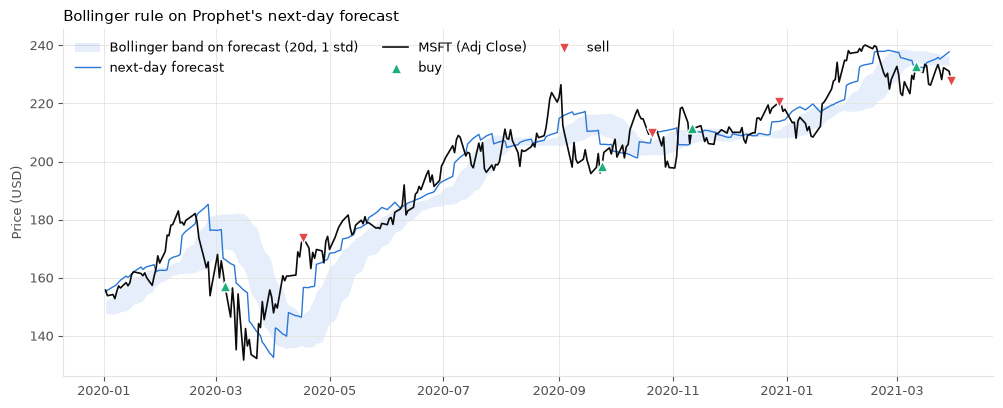

In [7]:
INK, MUTED, GRID_COLOR = "#0b0b0b", "#52514e", "#e4e3df"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
BUY, SELL = "#1baf7a", "#e34948"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID_COLOR, "axes.labelcolor": MUTED,
    "axes.titlesize": 11, "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID_COLOR, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 9,
    "legend.frameon": False, "lines.linewidth": 1.5,
})


def test_slice(series):
    return period(series, "test")


fc_series = forecast_series(close, forecasts)
bands = test_slice(bollinger(fc_series, 20, 1.0))
change = test_slice(results["bollinger_on_forecast"]["position"].diff())
px = test_slice(close)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(bands.index, bands["lower"], bands["upper"], color=BLUE,
                alpha=0.12, linewidth=0,
                label="Bollinger band on forecast (20d, 1 std)")
ax.plot(test_slice(fc_series), color=BLUE, linewidth=1,
        label="next-day forecast")
ax.plot(px, color=INK, linewidth=1.2, label="MSFT (Adj Close)")
ax.scatter(px.index[change > 0], px[change > 0], marker="^", s=60,
           color=BUY, edgecolor="white", linewidth=1, zorder=3, label="buy")
ax.scatter(px.index[change < 0], px[change < 0], marker="v", s=60,
           color=SELL, edgecolor="white", linewidth=1, zorder=3,
           label="sell")
ax.set_ylabel("Price (USD)")
ax.set_title("Bollinger rule on Prophet's next-day forecast")
ax.legend(loc="upper left", ncol=3)
plt.show()

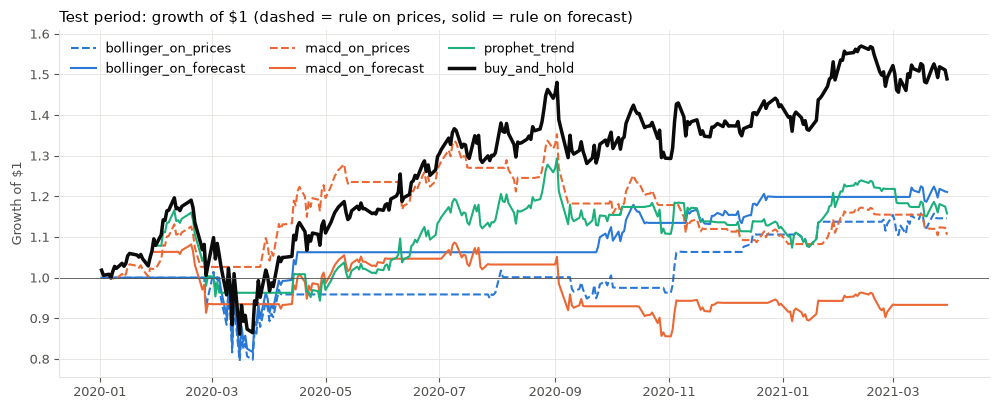

In [8]:
styles = {
    "bollinger_on_prices": (BLUE, "--"),
    "bollinger_on_forecast": (BLUE, "-"),
    "macd_on_prices": (ORANGE, "--"),
    "macd_on_forecast": (ORANGE, "-"),
    "prophet_trend": (AQUA, "-"),
}
fig, ax = plt.subplots(figsize=(12, 4.5))
for name, (color, dash) in styles.items():
    ret = test_slice(results[name]["ret"])
    ax.plot((1 + ret).cumprod(), color=color, linestyle=dash, label=name)
bh = test_slice(results["buy_and_hold"]["ret"])
ax.plot((1 + bh).cumprod(), color=INK, linewidth=2.5, label="buy_and_hold")
ax.axhline(1, color=MUTED, linewidth=0.6)
ax.set_ylabel("Growth of $1")
ax.set_title("Test period: growth of $1 (dashed = rule on prices, "
             "solid = rule on forecast)")
ax.legend(loc="upper left", ncol=3)
plt.show()

## What the results support

- **Tuning helps Prophet, but not enough.** The best settings
  (`changepoint_prior_scale=0.5`, additive) halve the error of the worst
  ones, yet still have about twice the error of "tomorrow = today", in
  both validation (2.2% vs 1.1%) and test (3.6% vs 1.7%).
- **Using the forecast instead of the price is not a reliable
  improvement.** In validation, MACD on the forecast beat MACD on prices
  while Bollinger on the forecast did worse. In the test period it was
  the other way round. A real edge would not flip like that.
- **No strategy comes close to buy-and-hold** in either period (90% and
  49%). The rules sit in cash much of the time while MSFT rose strongly.
- **The timing assumption matters a great deal.** Trading at the same
  close as the signal, with no costs, multiplies prophet_trend's
  validation return about fourfold. The original notebook's results
  relied on that kind of optimism, on top of tuning on the test period.

## Caveats

- One stock, chosen with hindsight; MSFT was one of the strongest large
  stocks of the period, which makes buy-and-hold hard to beat.
- Refitting weekly rather than daily is a compromise to keep the runtime
  reasonable. Between refits, Prophet's forecasts don't use the newest
  prices. `Prophet_Signal_Notebook.01` refits daily and reaches the same
  conclusion.
- A handful of trades per period is too few to tell skill from luck.